# Exploratory Data Analysis & Preprocessing

**Razorpay AI Buildathon 2026 - Track 02: AI Risk Manager**

Return-Risk Scorer for COD orders (Return-to-Origin prediction).

---

### The rule this notebook runs under

**Train split only. The test set is not opened here, and neither is validation.**

The test set is opened exactly once, in `05_final_evaluation.ipynb`, after the final
model has been chosen. Looking at it now -- even "just to check the distributions" --
would turn every number in `05` into an in-sample number. Section 1 puts a guard in
the way rather than relying on discipline.

### What this notebook has to produce

1. An honest account of which drivers carry signal and how much.
2. A **leakage audit** that measures the leak rather than asserting its absence.
3. A preprocessing pipeline definition that `03`, `04` and `05` all import.

## 1. Load splits (train only - never look at test)

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluate import (
    naive_target_encode,
    rate_table,
    single_feature_auc,
    variance_inflation,
)
from src.features import (
    CATEGORICAL_FEATURES,
    FORBIDDEN_FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    feature_columns,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

FIG = ROOT / "reports/figures"
RES = ROOT / "reports/results"
SEED = 20260101

In [2]:
# The guard. Any attempt to read the test split from this notebook fails loudly
# rather than quietly contaminating the final evaluation.
FORBIDDEN_SPLITS = {"test", "val"}


def load_split(name: str) -> pd.DataFrame:
    if name in FORBIDDEN_SPLITS:
        raise PermissionError(
            f"02_eda may not read the '{name}' split. The test set is opened once, "
            "in 05_final_evaluation.ipynb, after the final model is selected. "
            "Validation is first used in 03_model_training.ipynb."
        )
    return pd.read_parquet(ROOT / f"data/processed/{name}.parquet")


train = load_split("train")
print(f"train: {len(train):,} orders x {train.shape[1]} columns")
print(f"window: {train.order_ts.min():%Y-%m-%d} -> {train.order_ts.max():%Y-%m-%d}")

try:
    load_split("test")
except PermissionError as exc:
    print(f"\nguard active -> {exc}")

train: 35,000 orders x 42 columns
window: 2024-01-01 -> 2025-01-22

guard active -> 02_eda may not read the 'test' split. The test set is opened once, in 05_final_evaluation.ipynb, after the final model is selected. Validation is first used in 03_model_training.ipynb.


## 2. Schema & dtypes, missingness

In [3]:
schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
    "pct_missing": (train.isna().mean() * 100).round(2),
})
schema["role"] = np.where(
    schema.index == TARGET, "TARGET",
    np.where(schema.index.isin(feature_columns()), "feature",
             np.where(schema.index.isin(FORBIDDEN_FEATURES), "excluded", "derived-source")),
)
display(schema.sort_values(["role", "n_missing"], ascending=[True, False]))

,dtype,n_unique,n_missing,pct_missing,role
rto,int64,2,0,0.00,TARGET
order_id,object,35000,0,0.00,excluded
order_ts,datetime64[ns],31235,0,0.00,excluded
customer_id,object,13134,0,0.00,excluded
customer_name,object,12843,0,0.00,excluded
phone,object,13134,0,0.00,excluded
address_line,object,16383,0,0.00,excluded
pincode,object,2602,0,0.00,excluded
city,object,516,0,0.00,excluded
district,object,365,0,0.00,excluded


In [4]:
missing = schema[schema.n_missing > 0]
print("Columns with missing values:")
display(missing[["n_missing", "pct_missing"]])

print("""
past_rto_rate is the only column with missing values, and the missingness is
STRUCTURAL, not a data-quality problem: a customer's first ever order has no
prior orders to average over. It is deliberately left as NaN rather than filled
with 0, because 0 means "ordered before and never returned" -- a much better
customer than one we have never seen.

The pair (has_history, is_first_order) already encodes the distinction, so the
imputation in section 13 cannot erase it.
""")
print(f"first-order share: {train.is_first_order.mean():.1%}")
print(f"orders WITH history: {train.has_history.sum():,} ({train.has_history.mean():.1%})")

Columns with missing values:


,n_missing,pct_missing
past_rto_rate,13134,37.53



past_rto_rate is the only column with missing values, and the missingness is
STRUCTURAL, not a data-quality problem: a customer's first ever order has no
prior orders to average over. It is deliberately left as NaN rather than filled
with 0, because 0 means "ordered before and never returned" -- a much better
customer than one we have never seen.

The pair (has_history, is_first_order) already encodes the distinction, so the
imputation in section 13 cannot erase it.

first-order share: 37.5%
orders WITH history: 21,866 (62.5%)


## 3. Target balance and base rate

In [5]:
base = train[TARGET].mean()
cod = train[train.is_cod]
prepaid = train[~train.is_cod]

print(f"overall RTO base rate   {base:.4f}   ({train[TARGET].sum():,} of {len(train):,})")
print(f"COD RTO rate            {cod[TARGET].mean():.4f}   (n={len(cod):,})")
print(f"prepaid RTO rate        {prepaid[TARGET].mean():.4f}   (n={len(prepaid):,})")
print(f"imbalance ratio         1 : {(1 - base) / base:.2f}")
print()
print(f"A majority-class classifier scores {1 - base:.1%} ACCURACY and catches zero")
print("RTOs. Accuracy is not reported as a headline metric anywhere in this")
print("submission; PR-AUC is the selection metric, fixed in PRE_REGISTRATION.md.")

overall RTO base rate   0.1696   (5,937 of 35,000)
COD RTO rate            0.2658   (n=21,603)
prepaid RTO rate        0.0145   (n=13,397)
imbalance ratio         1 : 4.90

A majority-class classifier scores 83.0% ACCURACY and catches zero
RTOs. Accuracy is not reported as a headline metric anywhere in this
submission; PR-AUC is the selection metric, fixed in PRE_REGISTRATION.md.


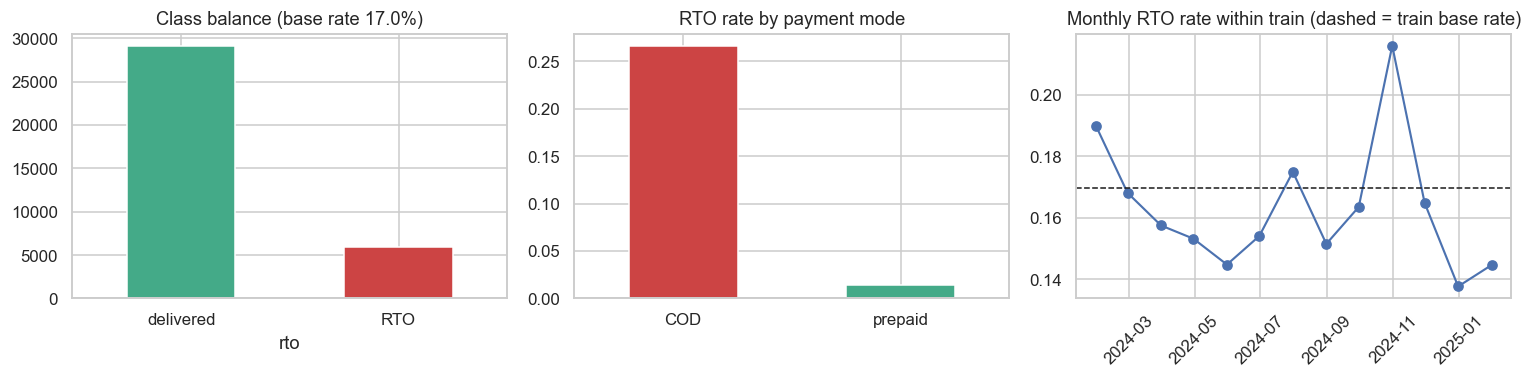

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

train[TARGET].value_counts().sort_index().plot(
    kind="bar", ax=ax[0], color=["#4a8", "#c44"])
ax[0].set_xticklabels(["delivered", "RTO"], rotation=0)
ax[0].set_title(f"Class balance (base rate {base:.1%})")

pd.Series({"COD": cod[TARGET].mean(), "prepaid": prepaid[TARGET].mean()}).plot(
    kind="bar", ax=ax[1], color=["#c44", "#4a8"])
ax[1].set_xticklabels(["COD", "prepaid"], rotation=0)
ax[1].set_title("RTO rate by payment mode")

monthly = train.set_index("order_ts")[TARGET].resample("ME").agg(["mean", "size"])
ax[2].plot(monthly.index, monthly["mean"], marker="o", lw=1.4)
ax[2].axhline(base, ls="--", c="k", lw=1)
ax[2].set_title("Monthly RTO rate within train (dashed = train base rate)")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG / "02_target_balance.png", bbox_inches="tight")
plt.show()

In [7]:
print("""Class-handling decision, made here and carried into 03:

  We do NOT oversample, and we do NOT use SMOTE.

  A 17% positive rate is imbalanced but not extreme, and resampling distorts the
  predicted probabilities. Our operating threshold is chosen at a RUPEE COST
  MINIMUM, which requires probabilities that mean what they say -- so calibration
  is a first-class metric here (Brier score + reliability diagram in 05), and
  anything that trades calibration for a prettier F1 is the wrong trade.

  Instead: class_weight='balanced' where the estimator supports it, PR-AUC for
  selection, and the threshold moved on the cost curve rather than the data moved
  under the threshold.""")

Class-handling decision, made here and carried into 03:

  We do NOT oversample, and we do NOT use SMOTE.

  A 17% positive rate is imbalanced but not extreme, and resampling distorts the
  predicted probabilities. Our operating threshold is chosen at a RUPEE COST
  MINIMUM, which requires probabilities that mean what they say -- so calibration
  is a first-class metric here (Brier score + reliability diagram in 05), and
  anything that trades calibration for a prettier F1 is the wrong trade.

  Instead: class_weight='balanced' where the estimator supports it, PR-AUC for
  selection, and the threshold moved on the cost curve rather than the data moved
  under the threshold.


## 4. Univariate distributions

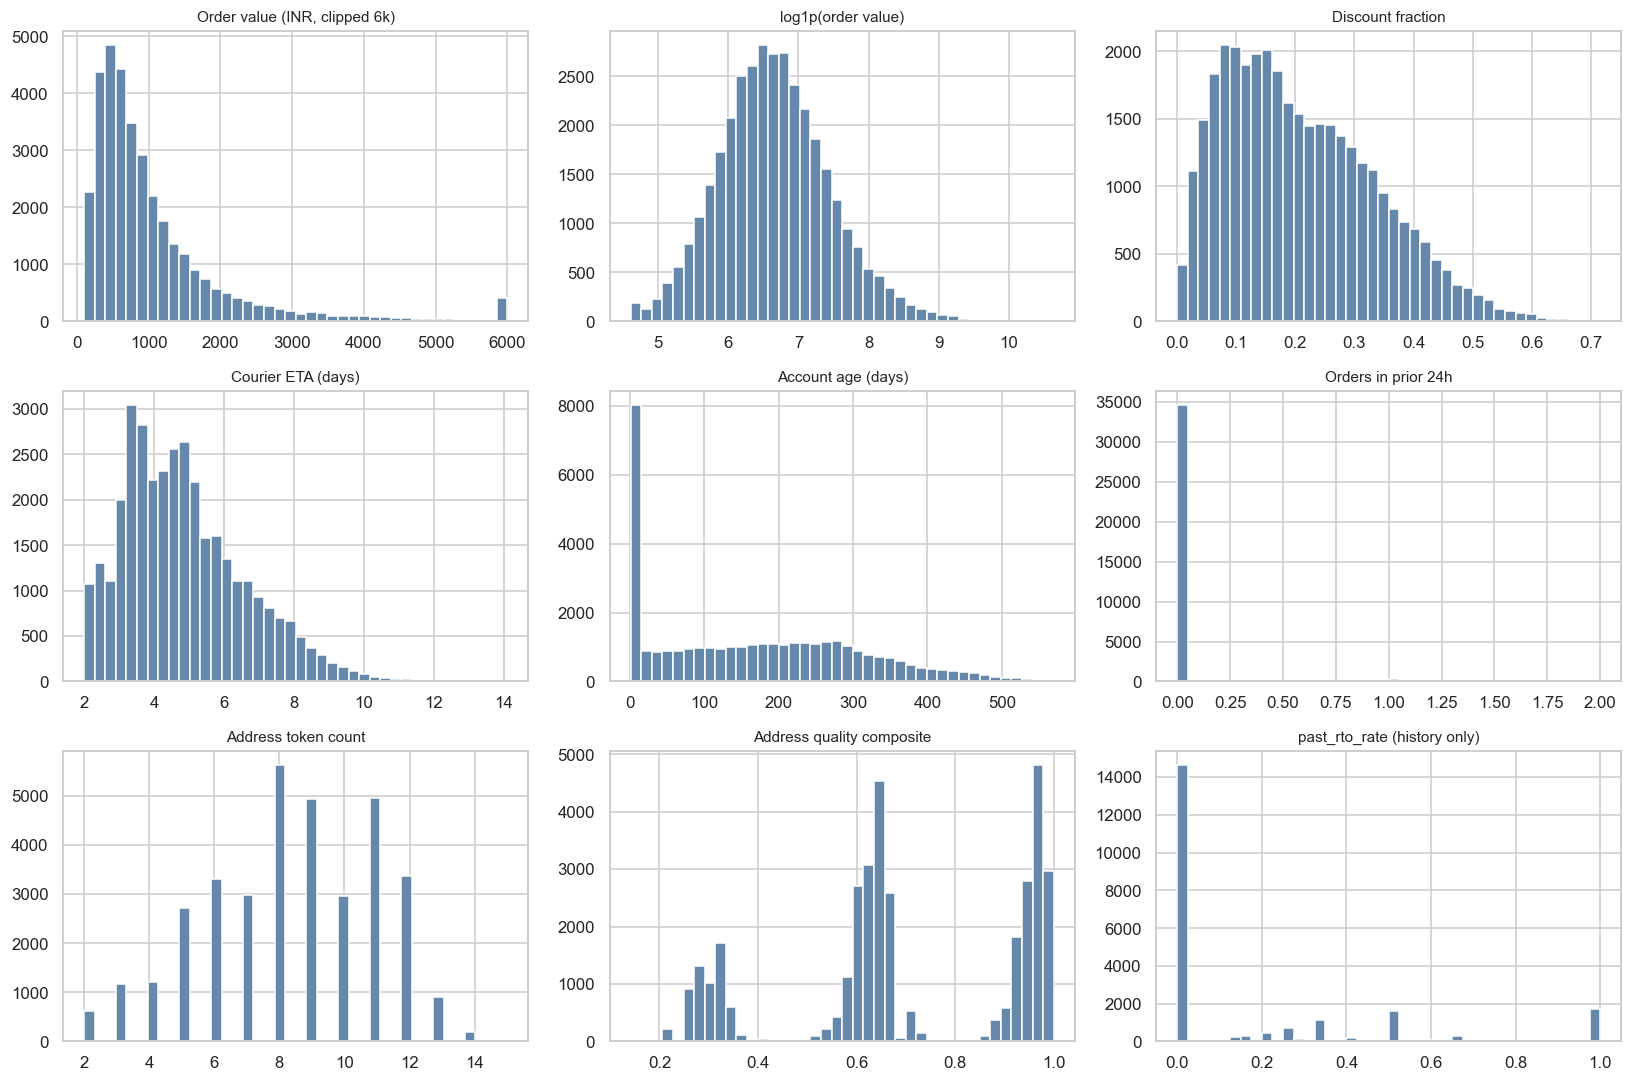

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plots = [
    ("order_value", "Order value (INR, clipped 6k)", lambda s: s.clip(upper=6000)),
    ("log_order_value", "log1p(order value)", None),
    ("discount_pct", "Discount fraction", None),
    ("delivery_days_est", "Courier ETA (days)", None),
    ("account_age_days", "Account age (days)", None),
    ("order_velocity_24h", "Orders in prior 24h", None),
    ("addr_token_count", "Address token count", None),
    ("addr_quality_score", "Address quality composite", None),
    ("past_rto_rate", "past_rto_rate (history only)", None),
]
for ax, (col, title, tf) in zip(axes.ravel(), plots):
    s = train[col].dropna()
    s = tf(s) if tf else s
    ax.hist(s, bins=40, color="#68a")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(FIG / "02_univariate_distributions.png", bbox_inches="tight")
plt.show()

In [9]:
display(train[NUMERIC_FEATURES].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
order_value,35000.0,1101.418,1287.948,99.000,457.000,756.000,1278.000,41896.000
log_order_value,35000.0,6.661,0.790,4.605,6.127,6.629,7.154,10.643
discount_pct,35000.0,0.210,0.127,0.001,0.107,0.188,0.295,0.715
discount_amount,35000.0,229.889,336.625,0.420,63.880,136.090,270.588,15492.910
delivery_days_est,35000.0,4.892,1.717,2.000,3.600,4.600,5.900,14.100
account_age_days,35000.0,168.083,138.933,1.150,26.758,158.770,272.850,569.750
log_account_age,35000.0,4.250,1.824,0.765,3.324,5.074,5.613,6.347
order_velocity_24h,35000.0,0.010,0.099,0.000,0.000,0.000,0.000,2.000
past_orders,35000.0,1.626,2.034,0.000,0.000,1.000,2.000,20.000
past_rto_count,35000.0,0.283,0.662,0.000,0.000,0.000,0.000,9.000


## 5. RTO rate by pincode tier / city

In [10]:
tier = rate_table(train, "pincode_tier").reindex(
    ["metro", "tier_1", "tier_2", "tier_3"])
display(tier.round(4))

print(f"\nspread metro -> tier_3: {tier.loc['tier_3','rate'] - tier.loc['metro','rate']:.1%} "
      f"absolute, lift {tier.loc['tier_3','lift_vs_base']:.2f}x vs base")

,n,positives,rate,ci_lo,ci_hi,lift_vs_base
pincode_tier,,,,,,
metro,10388,1341,0.1291,0.1228,0.1357,0.7610
tier_1,13911,2129,0.1530,0.1472,0.1591,0.9022
tier_2,7448,1584,0.2127,0.2035,0.2221,1.2538
tier_3,3253,883,0.2714,0.2564,0.2870,1.6002



spread metro -> tier_3: 14.2% absolute, lift 1.60x vs base


cities with >=150 train orders: 40


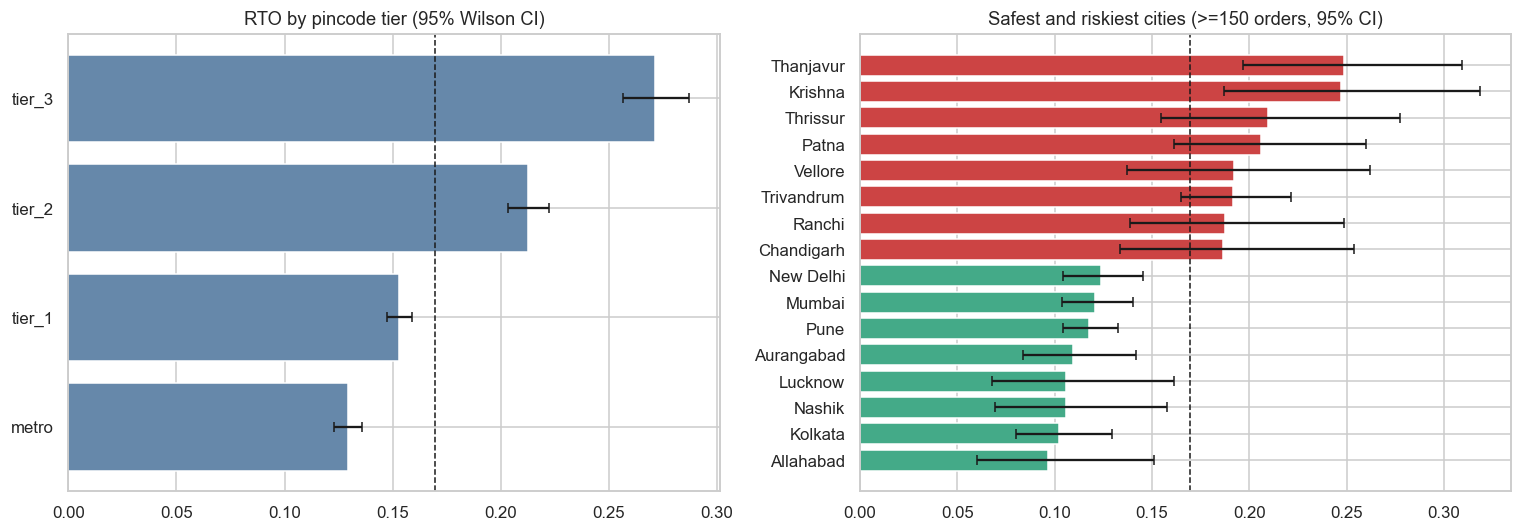

In [11]:
city = rate_table(train, "city", min_count=150).sort_values("rate")
print(f"cities with >=150 train orders: {len(city)}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

y = np.arange(len(tier))
ax[0].barh(y, tier["rate"], color="#68a")
ax[0].errorbar(tier["rate"], y,
               xerr=[tier["rate"] - tier["ci_lo"], tier["ci_hi"] - tier["rate"]],
               fmt="none", ecolor="k", capsize=3)
ax[0].set_yticks(y, tier.index)
ax[0].axvline(base, ls="--", c="k", lw=1)
ax[0].set_title("RTO by pincode tier (95% Wilson CI)")

ends = pd.concat([city.head(8), city.tail(8)])
y2 = np.arange(len(ends))
ax[1].barh(y2, ends["rate"],
           color=["#4a8"] * 8 + ["#c44"] * 8)
ax[1].errorbar(ends["rate"], y2,
               xerr=[ends["rate"] - ends["ci_lo"], ends["ci_hi"] - ends["rate"]],
               fmt="none", ecolor="k", capsize=3)
ax[1].set_yticks(y2, ends.index)
ax[1].axvline(base, ls="--", c="k", lw=1)
ax[1].set_title("Safest and riskiest cities (>=150 orders, 95% CI)")
plt.tight_layout()
plt.savefig(FIG / "02_rto_by_geography.png", bbox_inches="tight")
plt.show()

In [12]:
print("""Geography carries real signal, and the confidence intervals matter:

  The riskiest and safest cities differ by a wide margin, but the intervals on
  low-volume cities are wide enough that a raw per-city mean would be mostly
  noise. This is precisely why the pincode feature is SMOOTHED target encoding
  (shrink towards the prior by count) and not a raw group mean -- and why it is
  fitted OUT OF FOLD (section 12).""")
print(f"\nwidest CI among scored cities: "
      f"{(city['ci_hi'] - city['ci_lo']).max():.3f} at n={city.loc[(city['ci_hi'] - city['ci_lo']).idxmax(), 'n']:.0f}")
print(f"narrowest: {(city['ci_hi'] - city['ci_lo']).min():.3f} at "
      f"n={city.loc[(city['ci_hi'] - city['ci_lo']).idxmin(), 'n']:.0f}")

Geography carries real signal, and the confidence intervals matter:

  The riskiest and safest cities differ by a wide margin, but the intervals on
  low-volume cities are wide enough that a raw per-city mean would be mostly
  noise. This is precisely why the pincode feature is SMOOTHED target encoding
  (shrink towards the prior by count) and not a raw group mean -- and why it is
  fitted OUT OF FOLD (section 12).

widest CI among scored cities: 0.132 at n=162
narrowest: 0.028 at n=1991


## 6. RTO rate by order-value band (check the non-monotonic peak)

In [13]:
band = rate_table(train[train.is_cod], "order_value_band").reindex(
    ["under_500", "500_1000", "1000_plus"])
display(band.round(4))

peak_ok = band.loc["500_1000", "rate"] > max(
    band.loc["under_500", "rate"], band.loc["1000_plus", "rate"])
print(f"\nmiddle band is the peak: {peak_ok}")
print("This is the assumption most submissions get backwards. Risk does NOT rise")
print("with order value -- it peaks in the Rs500-1,000 impulse zone and falls above")
print("Rs1,000, where purchases are more considered.")

,n,positives,rate,ci_lo,ci_hi,lift_vs_base
order_value_band,,,,,,
under_500,7425,1917,0.2582,0.2484,0.2683,0.9712
500_1000,8039,2315,0.2880,0.2782,0.2980,1.0832
1000_plus,6139,1511,0.2461,0.2355,0.2571,0.9259



middle band is the peak: True
This is the assumption most submissions get backwards. Risk does NOT rise
with order value -- it peaks in the Rs500-1,000 impulse zone and falls above
Rs1,000, where purchases are more considered.


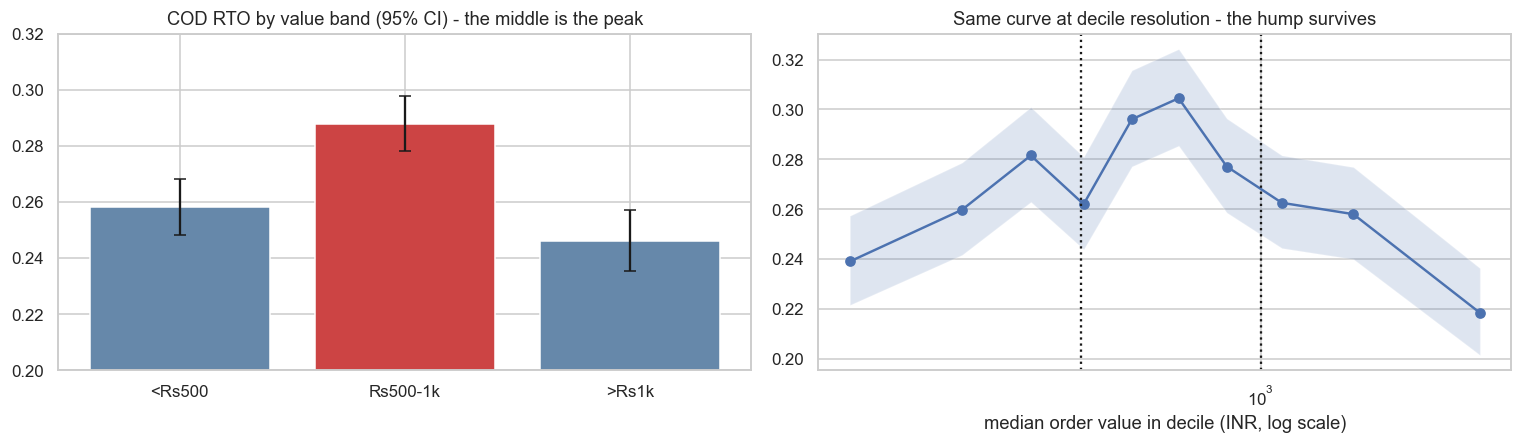

,n,median_value,rate,ci_lo,ci_hi
value_decile,,,,,
0,2184,206.0,0.2390,0.2216,0.2573
1,2156,317.0,0.2597,0.2417,0.2787
2,2149,413.0,0.2815,0.2629,0.3009
3,2168,506.0,0.2620,0.2439,0.2809
4,2155,609.0,0.2961,0.2772,0.3157
5,2161,729.0,0.3045,0.2854,0.3242
6,2158,877.0,0.2771,0.2586,0.2964
7,2152,1084.0,0.2625,0.2444,0.2815
8,2159,1427.0,0.2580,0.2400,0.2769


In [14]:
# Is the peak an artefact of three coarse bins? Check the shape at decile
# resolution, which no binning choice can manufacture.
cod_tr = train[train.is_cod].copy()
cod_tr["value_decile"] = pd.qcut(cod_tr.order_value, 10, labels=False, duplicates="drop")
dec = rate_table(cod_tr, "value_decile")
dec["median_value"] = cod_tr.groupby("value_decile")["order_value"].median()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

x = np.arange(len(band))
ax[0].bar(x, band["rate"], color=["#68a", "#c44", "#68a"])
ax[0].errorbar(x, band["rate"],
               yerr=[band["rate"] - band["ci_lo"], band["ci_hi"] - band["rate"]],
               fmt="none", ecolor="k", capsize=4)
ax[0].set_xticks(x, ["<Rs500", "Rs500-1k", ">Rs1k"])
ax[0].set_ylim(0.20, 0.32)
ax[0].set_title("COD RTO by value band (95% CI) - the middle is the peak")

ax[1].plot(dec["median_value"], dec["rate"], "o-", lw=1.6)
ax[1].fill_between(dec["median_value"], dec["ci_lo"], dec["ci_hi"], alpha=0.18)
ax[1].set_xscale("log")
ax[1].axvline(500, ls=":", c="k"); ax[1].axvline(1000, ls=":", c="k")
ax[1].set_xlabel("median order value in decile (INR, log scale)")
ax[1].set_title("Same curve at decile resolution - the hump survives")
plt.tight_layout()
plt.savefig(FIG / "02_order_value_curve.png", bbox_inches="tight")
plt.show()

display(dec[["n", "median_value", "rate", "ci_lo", "ci_hi"]].round(4))

## 7. RTO rate by category, COD vs prepaid

In [15]:
cat = rate_table(train, "category").sort_values("rate", ascending=False)
display(cat.round(4))

pay_cat = (train.pivot_table(index="category", columns="is_cod",
                             values=TARGET, aggfunc="mean")
           .rename(columns={False: "prepaid", True: "COD"}))
display(pay_cat.round(4))

,n,positives,rate,ci_lo,ci_hi,lift_vs_base
category,,,,,,
fashion,10431,2991,0.2867,0.2781,0.2955,1.6904
footwear,3869,615,0.1590,0.1478,0.1708,0.9371
accessories,4919,731,0.1486,0.1389,0.1588,0.8761
beauty,4549,606,0.1332,0.1237,0.1434,0.7853
home_kitchen,6089,663,0.1089,0.1013,0.1170,0.6419
electronics,5143,331,0.0644,0.0580,0.0714,0.3794


is_cod,prepaid,COD
category,,
accessories,0.0174,0.2025
beauty,0.0145,0.1929
electronics,0.0083,0.1523
fashion,0.0189,0.4126
footwear,0.0178,0.2447
home_kitchen,0.0128,0.1761


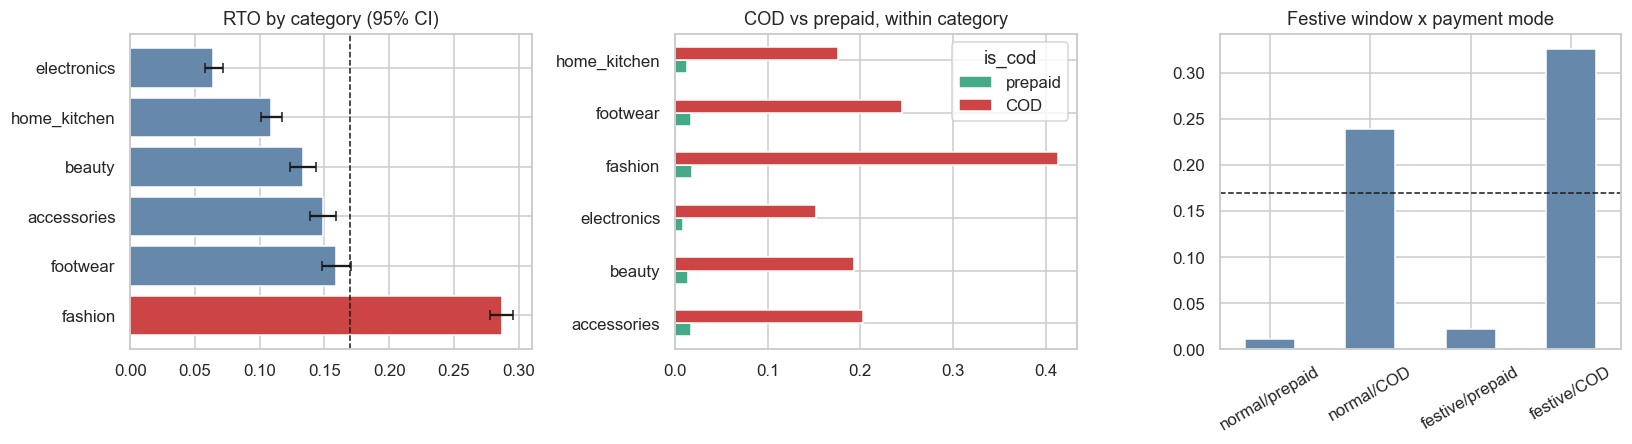

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

y = np.arange(len(cat))
ax[0].barh(y, cat["rate"], color=["#c44" if i == "fashion" else "#68a" for i in cat.index])
ax[0].errorbar(cat["rate"], y,
               xerr=[cat["rate"] - cat["ci_lo"], cat["ci_hi"] - cat["rate"]],
               fmt="none", ecolor="k", capsize=3)
ax[0].set_yticks(y, cat.index)
ax[0].axvline(base, ls="--", c="k", lw=1)
ax[0].set_title("RTO by category (95% CI)")

pay_cat.plot(kind="barh", ax=ax[1], color=["#4a8", "#c44"])
ax[1].set_title("COD vs prepaid, within category")
ax[1].set_ylabel("")

fest = rate_table(train, ["is_festive", "is_cod"])
fest.index = [f"{'festive' if a else 'normal'}/{'COD' if b else 'prepaid'}"
              for a, b in fest.index]
fest["rate"].plot(kind="bar", ax=ax[2], color="#68a", rot=30)
ax[2].axhline(base, ls="--", c="k", lw=1)
ax[2].set_title("Festive window x payment mode")
plt.tight_layout()
plt.savefig(FIG / "02_rto_by_category_payment.png", bbox_inches="tight")
plt.show()

In [17]:
print("""Payment mode is the dominant single driver -- COD RTO runs an order of
magnitude above prepaid. That is exactly why the product is a COD gate rather
than a general returns model, and why the three-tier policy in 05 acts on the
COD option specifically.

Category ordering is stable and matches the published picture: fashion worst,
electronics best. The COD/prepaid gap holds WITHIN every category, so category
is not merely a proxy for payment mode.""")

Payment mode is the dominant single driver -- COD RTO runs an order of
magnitude above prepaid. That is exactly why the product is a COD gate rather
than a general returns model, and why the three-tier policy in 05 acts on the
COD option specifically.

Category ordering is stable and matches the published picture: fashion worst,
electronics best. The COD/prepaid gap holds WITHIN every category, so category
is not merely a proxy for payment mode.


## 8. Customer history effects

In [18]:
hist = train[train.has_history == 1].copy()
hist["past_rto_bucket"] = pd.cut(
    hist.past_rto_rate, [-0.01, 0.0, 0.25, 0.5, 0.75, 1.01],
    labels=["0%", "1-25%", "26-50%", "51-75%", "76-100%"])

by_hist = rate_table(hist, "past_rto_bucket")
display(by_hist.round(4))

first_vs_repeat = rate_table(train, "is_first_order")
first_vs_repeat.index = ["repeat customer", "first order"]
display(first_vs_repeat.round(4))

,n,positives,rate,ci_lo,ci_hi,lift_vs_base
past_rto_bucket,,,,,,
0%,14651,2084,0.1422,0.1367,0.1480,0.8561
1-25%,1803,316,0.1753,0.1584,0.1935,1.0549
26-50%,3211,672,0.2093,0.1956,0.2237,1.2596
51-75%,449,138,0.3073,0.2665,0.3515,1.8499
76-100%,1752,423,0.2414,0.2220,0.2620,1.4531


,n,positives,rate,ci_lo,ci_hi,lift_vs_base
repeat customer,21866,3633,0.1661,0.1613,0.1711,0.9795
first order,13134,2304,0.1754,0.1690,0.1820,1.0342


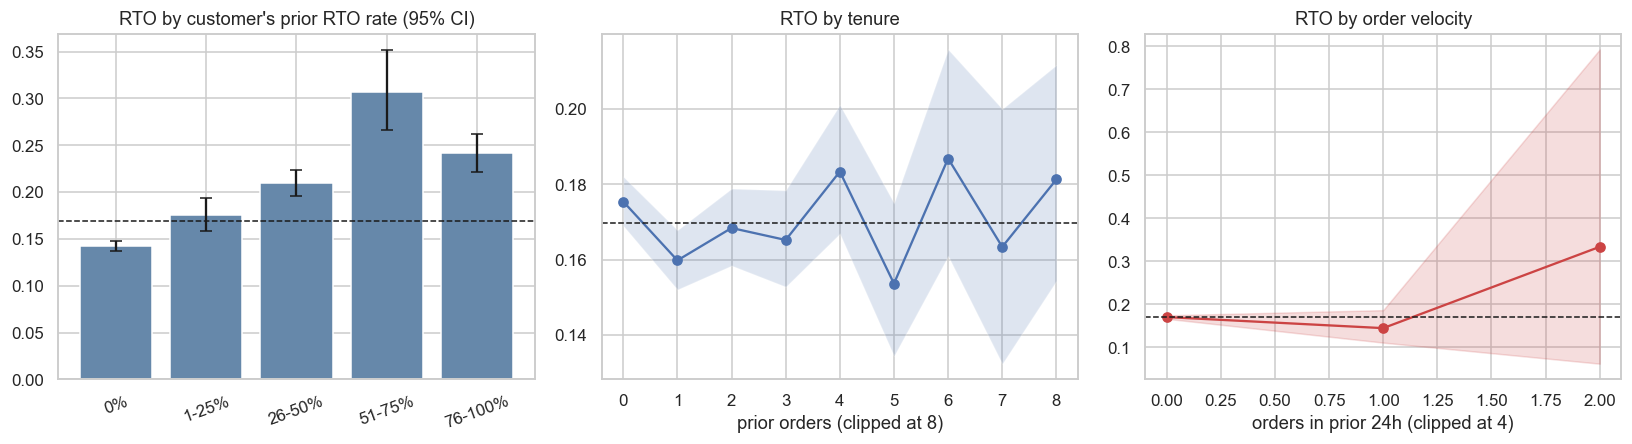

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

x = np.arange(len(by_hist))
ax[0].bar(x, by_hist["rate"], color="#68a")
ax[0].errorbar(x, by_hist["rate"],
               yerr=[by_hist["rate"] - by_hist["ci_lo"], by_hist["ci_hi"] - by_hist["rate"]],
               fmt="none", ecolor="k", capsize=4)
ax[0].set_xticks(x, by_hist.index, rotation=20)
ax[0].axhline(base, ls="--", c="k", lw=1)
ax[0].set_title("RTO by customer's prior RTO rate (95% CI)")

npast = rate_table(train.assign(n_past=train.past_orders.clip(upper=8)), "n_past")
ax[1].plot(npast.index, npast["rate"], "o-")
ax[1].fill_between(npast.index, npast["ci_lo"], npast["ci_hi"], alpha=0.18)
ax[1].axhline(base, ls="--", c="k", lw=1)
ax[1].set_xlabel("prior orders (clipped at 8)")
ax[1].set_title("RTO by tenure")

vel = rate_table(train.assign(v=train.order_velocity_24h.clip(upper=4)), "v")
ax[2].plot(vel.index, vel["rate"], "o-", color="#c44")
ax[2].fill_between(vel.index, vel["ci_lo"], vel["ci_hi"], alpha=0.18, color="#c44")
ax[2].axhline(base, ls="--", c="k", lw=1)
ax[2].set_xlabel("orders in prior 24h (clipped at 4)")
ax[2].set_title("RTO by order velocity")
plt.tight_layout()
plt.savefig(FIG / "02_customer_history.png", bbox_inches="tight")
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score as _auc

auc_hist = single_feature_auc(hist, ["past_rto_rate"]).auc.iat[0]
# What the MODEL actually sees: NaN replaced by the training median, exactly as
# the pipeline in section 13 will impute it.
imputed = train.past_rto_rate.fillna(train.past_rto_rate.median())
auc_imputed = _auc(train[TARGET], imputed)

print("past_rto_rate carries two different numbers, and the gap is the point:")
print(f"  on customers WITH history (n={len(hist):,})      : AUC {auc_hist:.4f}")
print(f"  on all train rows, median-imputed (n={len(train):,}) : AUC {auc_imputed:.4f}")
print()
print(f"""Diluting the feature across the {train.is_first_order.mean():.0%} of orders that have no
history costs {auc_hist - auc_imputed:.3f} AUC. The feature is genuinely predictive -- but only
for the {train.has_history.mean():.0%} of orders it can speak about at all.

That asymmetry is worth stating plainly: for a first-time customer the model is
working from geography, address quality and basket alone. 05 reports first-order
performance separately in the exception list.""")

weak = single_feature_auc(
    train, ["order_velocity_24h", "past_orders", "account_age_days",
            "is_alternate_address", "is_first_order"])
display(weak.round(4))
zero_vel = (train.order_velocity_24h == 0).mean()
print(f"""
Two of the features on the engineering list are near-null on their own, and we
are saying so now rather than letting SHAP say it in 05:

  order_velocity_24h  AUC {weak.set_index('feature').loc['order_velocity_24h','auc']:.4f}. {zero_vel:.1%} of orders have a velocity of ZERO.
                      A feature that is constant for {zero_vel:.0%} of rows cannot move a
                      marginal AUC no matter how informative its tail is. Rapid
                      re-ordering is a real fraud signal in production data; in
                      this generated population it is simply too rare to learn
                      from, and we are not going to inflate its frequency to make
                      the feature look better.

  account_age_days    AUC {weak.set_index('feature').loc['account_age_days','auc']:.4f}. Nearly all of its apparent effect is already
                      carried by has_history, with which it is close to collinear.

Both are KEPT -- a tree can still split on the thin tail, and dropping features
because their marginal AUC is unimpressive is how interaction effects get thrown
away. But they are declared weak here, before any model has seen them, so that a
SHAP plot in 05 showing them contributing nothing reads as a confirmed prediction
rather than a surprise. If they contribute nothing there, they go in the honest
exception list.""")

past_rto_rate carries two different numbers, and the gap is the point:
  on customers WITH history (n=21,866)      : AUC 0.5646
  on all train rows, median-imputed (n=35,000) : AUC 0.5356

Diluting the feature across the 38% of orders that have no
history costs 0.029 AUC. The feature is genuinely predictive -- but only
for the 62% of orders it can speak about at all.

That asymmetry is worth stating plainly: for a first-time customer the model is
working from geography, address quality and basket alone. 05 reports first-order
performance separately in the exception list.


,feature,auc,signed_auc,n_used
0,is_first_order,0.5077,0.5077,35000
1,account_age_days,0.5077,0.4923,35000
2,is_alternate_address,0.5056,0.5056,35000
3,past_orders,0.5037,0.4963,35000
4,order_velocity_24h,0.5008,0.4992,35000



Two of the features on the engineering list are near-null on their own, and we
are saying so now rather than letting SHAP say it in 05:

  order_velocity_24h  AUC 0.5008. 99.0% of orders have a velocity of ZERO.
                      A feature that is constant for 99% of rows cannot move a
                      marginal AUC no matter how informative its tail is. Rapid
                      re-ordering is a real fraud signal in production data; in
                      this generated population it is simply too rare to learn
                      from, and we are not going to inflate its frequency to make
                      the feature look better.

  account_age_days    AUC 0.5077. Nearly all of its apparent effect is already
                      carried by has_history, with which it is close to collinear.

Both are KEPT -- a tree can still split on the thin tail, and dropping features
because their marginal AUC is unimpressive is how interaction effects get thrown
away. But they 

## 9. Address-quality effects

In [21]:
addr_cols = ["addr_has_house_number", "addr_has_landmark", "addr_token_count",
             "addr_char_len", "addr_digit_count", "addr_comma_count",
             "addr_gibberish_score", "addr_quality_score"]

flags = pd.concat([
    rate_table(train, "addr_has_house_number").assign(feature="has_house_number"),
    rate_table(train, "addr_has_landmark").assign(feature="has_landmark"),
])
display(flags.round(4))

q = train.copy()
q["quality_q"] = pd.qcut(q.addr_quality_score, 5, labels=False, duplicates="drop")
by_q = rate_table(q, "quality_q")
display(by_q.round(4))

,n,positives,rate,ci_lo,ci_hi,lift_vs_base,feature
0,11238,2093,0.1862,0.1792,0.1935,1.0979,has_house_number
1,23762,3844,0.1618,0.1571,0.1665,0.9537,has_house_number
0,16272,2900,0.1782,0.1724,0.1842,1.0506,has_landmark
1,18728,3037,0.1622,0.1570,0.1675,0.9560,has_landmark


,n,positives,rate,ci_lo,ci_hi,lift_vs_base
quality_q,,,,,,
0,7719,1476,0.1912,0.1826,0.2001,1.1273
1,6310,1166,0.1848,0.1754,0.1946,1.0894
2,7336,1178,0.1606,0.1524,0.1692,0.9466
3,10334,1602,0.1550,0.1482,0.1621,0.9139
4,3301,515,0.1560,0.1440,0.1688,0.9197


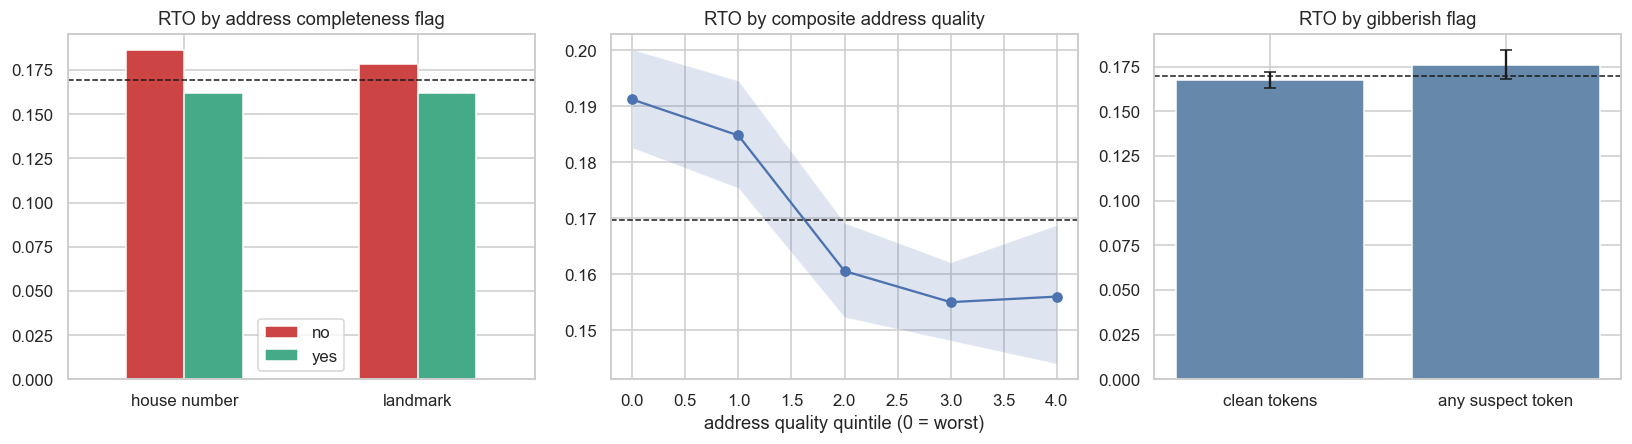

,feature,auc,signed_auc,n_used
0,addr_quality_score,0.5307,0.4693,35000
1,addr_token_count,0.5296,0.4704,35000
2,addr_char_len,0.5227,0.4773,35000
3,addr_comma_count,0.5204,0.4796,35000
4,addr_digit_count,0.5192,0.4808,35000
5,addr_has_house_number,0.5189,0.4811,35000
6,addr_has_landmark,0.5142,0.4858,35000
7,addr_gibberish_score,0.5073,0.5073,35000


In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

pd.DataFrame({
    "no": [rate_table(train, "addr_has_house_number").loc[0, "rate"],
           rate_table(train, "addr_has_landmark").loc[0, "rate"]],
    "yes": [rate_table(train, "addr_has_house_number").loc[1, "rate"],
            rate_table(train, "addr_has_landmark").loc[1, "rate"]],
}, index=["house number", "landmark"]).plot(kind="bar", ax=ax[0], rot=0,
                                            color=["#c44", "#4a8"])
ax[0].axhline(base, ls="--", c="k", lw=1)
ax[0].set_title("RTO by address completeness flag")

ax[1].plot(by_q.index, by_q["rate"], "o-")
ax[1].fill_between(by_q.index, by_q["ci_lo"], by_q["ci_hi"], alpha=0.18)
ax[1].axhline(base, ls="--", c="k", lw=1)
ax[1].set_xlabel("address quality quintile (0 = worst)")
ax[1].set_title("RTO by composite address quality")

gib = train.assign(g=(train.addr_gibberish_score > 0).astype(int))
gr = rate_table(gib, "g")
ax[2].bar([0, 1], gr["rate"], color="#68a")
ax[2].errorbar([0, 1], gr["rate"],
               yerr=[gr["rate"] - gr["ci_lo"], gr["ci_hi"] - gr["rate"]],
               fmt="none", ecolor="k", capsize=4)
ax[2].set_xticks([0, 1], ["clean tokens", "any suspect token"])
ax[2].axhline(base, ls="--", c="k", lw=1)
ax[2].set_title("RTO by gibberish flag")
plt.tight_layout()
plt.savefig(FIG / "02_address_quality.png", bbox_inches="tight")
plt.show()

display(single_feature_auc(train, addr_cols).round(4))

In [23]:
print("""Honest read on the address block:

  The composite quality score and the completeness flags carry a real, modest
  effect. addr_gibberish_score is the WEAKEST of the eight -- barely above
  chance on its own.

  Why it is weak: the detector fires on genuine low-vowel Indian place tokens
  (Kshetra, Bhavnagar) as well as on mangled ones, so its precision as a
  "bad address" signal is poor. We are keeping it, because the tree models can
  use it conditionally on the other address features, but we are NOT going to
  claim it as a headline feature. If SHAP in 05 shows it contributing nothing,
  that goes in the exception list rather than getting quietly dropped.""")

Honest read on the address block:

  The composite quality score and the completeness flags carry a real, modest
  effect. addr_gibberish_score is the WEAKEST of the eight -- barely above
  chance on its own.

  Why it is weak: the detector fires on genuine low-vowel Indian place tokens
  (Kshetra, Bhavnagar) as well as on mangled ones, so its precision as a
  "bad address" signal is poor. We are keeping it, because the tree models can
  use it conditionally on the other address features, but we are NOT going to
  claim it as a headline feature. If SHAP in 05 shows it contributing nothing,
  that goes in the exception list rather than getting quietly dropped.


## 10. Correlation & multicollinearity

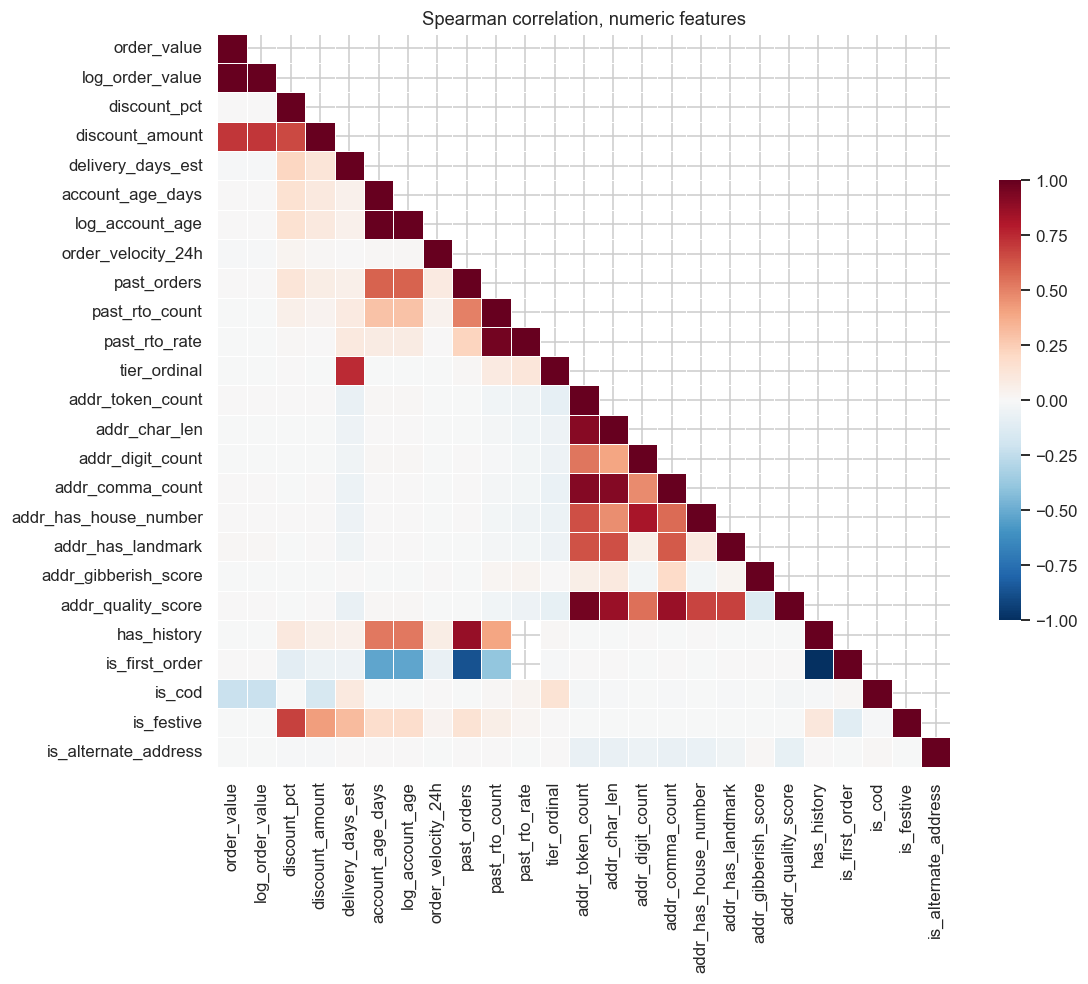

,a,b,rho,abs_rho
0,order_value,log_order_value,1.000,1.000
110,account_age_days,log_account_age,1.000,1.000
288,has_history,is_first_order,-1.000,1.000
180,past_rto_count,past_rto_rate,0.965,0.965
226,addr_token_count,addr_quality_score,0.962,0.962
222,addr_token_count,addr_comma_count,0.916,0.916
233,addr_char_len,addr_comma_count,0.914,0.914
220,addr_token_count,addr_char_len,0.912,0.912
175,past_orders,has_history,0.870,0.870
176,past_orders,is_first_order,-0.870,0.870


In [24]:
num = train[NUMERIC_FEATURES].astype(float)
corr = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Spearman correlation, numeric features")
plt.tight_layout()
plt.savefig(FIG / "02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

pairs = (corr.where(mask).stack().rename("rho").reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"}))
pairs["abs_rho"] = pairs.rho.abs()
display(pairs.sort_values("abs_rho", ascending=False).head(12).round(3))

In [25]:
vif = variance_inflation(num)
display(vif.head(12).round(2))

,feature,r2_vs_others,vif
0,is_first_order,1.00,inf
1,has_history,1.00,inf
2,addr_quality_score,1.00,2085.37
3,addr_has_landmark,1.00,579.12
4,addr_has_house_number,1.00,519.07
5,addr_token_count,0.99,146.93
6,addr_gibberish_score,0.93,14.76
7,addr_char_len,0.90,10.26
8,addr_comma_count,0.90,9.53
9,log_account_age,0.80,4.93


In [26]:
print("""Multicollinearity: identified, kept, and handled per model.

  The high-VIF clusters are all constructions we made on purpose:
    order_value / log_order_value / discount_amount
    past_orders / past_rto_count / has_history / is_first_order
    addr_token_count / addr_char_len / addr_comma_count / addr_quality_score

  Decision: KEEP all of them.

  Tree ensembles are unaffected by collinearity for predictive performance --
  it only splits the credit in the importance ranking, which we account for in
  05 by reading SHAP over feature GROUPS as well as individual columns.

  Logistic regression IS affected: coefficients become unstable and their signs
  can flip. It is therefore fitted with L2 regularisation and standardised
  inputs (section 13), which is the standard remedy, and we do not interpret
  its individual coefficients as causal effects anywhere in this submission.

  We are NOT dropping columns to make a correlation heatmap look tidy. Dropping
  log_order_value would help the linear model and cost the tree models a useful
  monotone transform.""")

Multicollinearity: identified, kept, and handled per model.

  The high-VIF clusters are all constructions we made on purpose:
    order_value / log_order_value / discount_amount
    past_orders / past_rto_count / has_history / is_first_order
    addr_token_count / addr_char_len / addr_comma_count / addr_quality_score

  Decision: KEEP all of them.

  Tree ensembles are unaffected by collinearity for predictive performance --
  it only splits the credit in the importance ranking, which we account for in
  05 by reading SHAP over feature GROUPS as well as individual columns.

  Logistic regression IS affected: coefficients become unstable and their signs
  can flip. It is therefore fitted with L2 regularisation and standardised
  inputs (section 13), which is the standard remedy, and we do not interpret
  its individual coefficients as causal effects anywhere in this submission.

  We are NOT dropping columns to make a correlation heatmap look tidy. Dropping
  log_order_value would help

## 11. Outliers

In [27]:
out_cols = ["order_value", "discount_amount", "account_age_days",
            "order_velocity_24h", "delivery_days_est", "addr_char_len"]

rows = []
for c in out_cols:
    s = train[c].astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    hi = q3 + 3 * iqr
    rows.append({
        "feature": c, "p50": s.median(), "p99": s.quantile(0.99), "max": s.max(),
        "n_beyond_3iqr": int((s > hi).sum()),
        "pct_beyond_3iqr": round((s > hi).mean() * 100, 3),
        "rto_rate_in_tail": round(train.loc[s > hi, TARGET].mean(), 4) if (s > hi).any() else np.nan,
    })
display(pd.DataFrame(rows).round(3))

,feature,p50,p99,max,n_beyond_3iqr,pct_beyond_3iqr,rto_rate_in_tail
0,order_value,756.00,6185.03,41896.00,1154,3.297,0.054
1,discount_amount,136.09,1522.82,15492.91,1188,3.394,0.089
2,account_age_days,158.77,495.00,569.75,0,0.000,NaN
3,order_velocity_24h,0.00,0.00,2.00,336,0.960,0.146
4,delivery_days_est,4.60,9.60,14.10,6,0.017,0.333
5,addr_char_len,50.00,79.00,94.00,0,0.000,NaN


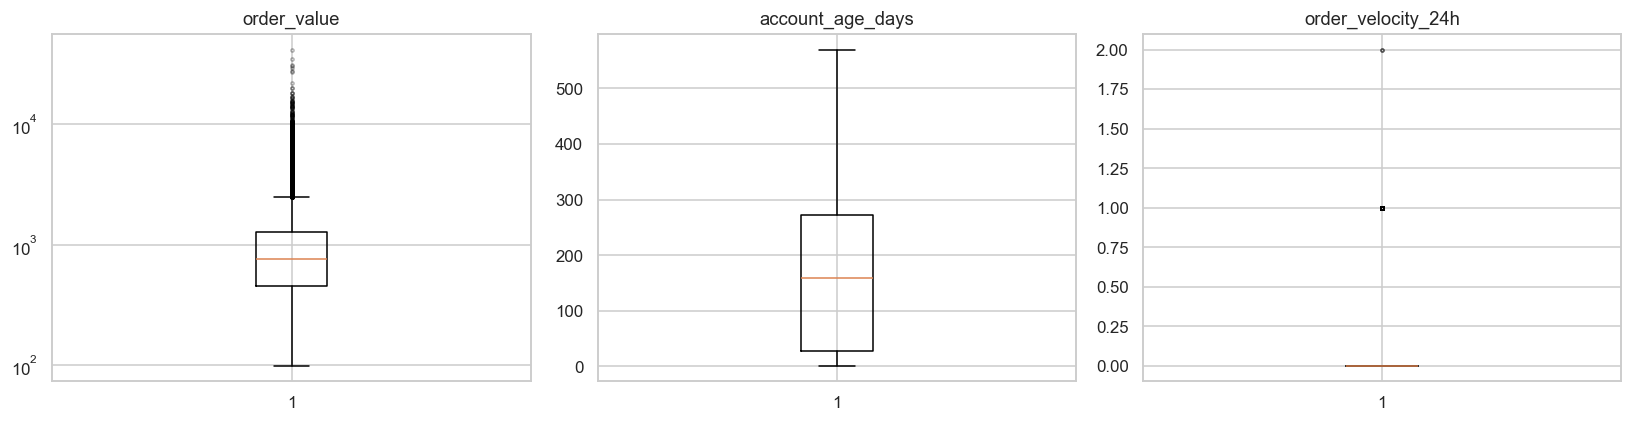

Outlier decision: KEEP, do not clip, do not winsorise.

  The tails here are behaviour, not corruption. A Rs40,000 electronics order and
  a customer placing five orders in an hour are exactly the cases a risk scorer
  exists to reason about; clipping them would remove the signal we are being
  paid to find.

  What we do instead: log1p transforms (log_order_value, log_account_age) are
  already columns, so linear models see a compressed scale without the raw values
  being destroyed for the trees.

  There are no impossible values -- no negative order values, no negative account
  ages, no RTO flags outside {0,1}. Verified below.

integrity assertions passed


In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, ["order_value", "account_age_days", "order_velocity_24h"]):
    a.boxplot(train[c].astype(float), vert=True, showfliers=True,
              flierprops={"markersize": 2, "alpha": 0.3})
    a.set_title(c)
    if c == "order_value":
        a.set_yscale("log")
plt.tight_layout()
plt.savefig(FIG / "02_outliers.png", bbox_inches="tight")
plt.show()

print("""Outlier decision: KEEP, do not clip, do not winsorise.

  The tails here are behaviour, not corruption. A Rs40,000 electronics order and
  a customer placing five orders in an hour are exactly the cases a risk scorer
  exists to reason about; clipping them would remove the signal we are being
  paid to find.

  What we do instead: log1p transforms (log_order_value, log_account_age) are
  already columns, so linear models see a compressed scale without the raw values
  being destroyed for the trees.

  There are no impossible values -- no negative order values, no negative account
  ages, no RTO flags outside {0,1}. Verified below.""")

assert (train.order_value > 0).all()
assert (train.account_age_days >= 0).all()
assert train[TARGET].isin([0, 1]).all()
assert (train.past_rto_count <= train.past_orders).all()
assert train.order_ts.is_monotonic_increasing
print("\nintegrity assertions passed")

## 12. Leakage audit

In [29]:
print("=" * 74)
print("LEAKAGE AUDIT")
print("=" * 74)

# 1. No forbidden column can reach the model.
leaked = set(feature_columns()) & set(FORBIDDEN_FEATURES)
print(f"\n[1] forbidden columns present in the feature list : {sorted(leaked) or 'none'}")
assert not leaked

present_latents = [c for c in train.columns if c.startswith("_")]
print(f"    generator latents present in processed data    : {present_latents or 'none'}")
assert not present_latents, "latents must never reach data/processed"

# 2. Chronological integrity.
print(f"\n[2] train is time-ordered                          : {train.order_ts.is_monotonic_increasing}")
print(f"    train ends                                     : {train.order_ts.max():%Y-%m-%d}")

# 3. Customer history is strictly backward-looking.
print(f"\n[3] past_rto_count <= past_orders everywhere       : "
      f"{(train.past_rto_count <= train.past_orders).all()}")
print(f"    velocity_24h <= past_orders everywhere         : "
      f"{(train.order_velocity_24h <= train.past_orders).all()}")
print(f"    first orders carry no history                  : "
      f"{train.loc[train.past_orders == 0, 'past_rto_rate'].isna().all()}")

LEAKAGE AUDIT

[1] forbidden columns present in the feature list : none
    generator latents present in processed data    : none

[2] train is time-ordered                          : True
    train ends                                     : 2025-01-22

[3] past_rto_count <= past_orders everywhere       : True
    velocity_24h <= past_orders everywhere         : True
    first orders carry no history                  : True


In [30]:
# 4. Univariate AUC screen. Any single raw feature approaching the whole-model
#    AUC deserves an explanation before it is trusted.
BAYES_CEILING_AUC = json.load(open(RES / "01_calibration.json"))["bayes_ceiling"]["roc_auc"]

screen = single_feature_auc(train, NUMERIC_FEATURES)
screen["flag"] = np.where(screen.auc > 0.80, "INVESTIGATE", "")
display(screen.round(4))

print(f"\nBayes ceiling (whole-model, from 01): ROC-AUC {BAYES_CEILING_AUC:.4f}")
print(f"strongest single feature            : {screen.feature.iat[0]} at {screen.auc.iat[0]:.4f}")
assert screen.auc.max() < 0.80, "a single feature is suspiciously predictive - investigate"
print("\nNo single feature is anywhere near the ceiling. Signal is distributed,")
print("which is what an honest problem looks like.")

,feature,auc,signed_auc,n_used,flag
0,is_cod,0.7108,0.7108,35000,
1,delivery_days_est,0.5910,0.5910,35000,
2,tier_ordinal,0.5803,0.5803,35000,
3,past_rto_rate,0.5646,0.5646,21866,
4,order_value,0.5624,0.4376,35000,
5,log_order_value,0.5624,0.4376,35000,
6,discount_pct,0.5510,0.5510,35000,
7,is_festive,0.5425,0.5425,35000,
8,past_rto_count,0.5344,0.5344,35000,
9,addr_quality_score,0.5307,0.4693,35000,



Bayes ceiling (whole-model, from 01): ROC-AUC 0.8692
strongest single feature            : is_cod at 0.7108

No single feature is anywhere near the ceiling. Signal is distributed,
which is what an honest problem looks like.


In [31]:
# 5. THE ONE THAT MATTERS: target encoding.
#    We measure the leak rather than asserting it is absent. `naive_target_encode`
#    is the WRONG implementation, included in src/evaluate.py purely so its
#    damage can be quantified here. It never trains anything.
from src.features import OutOfFoldTargetEncoder
from sklearn.metrics import roc_auc_score

y = train[TARGET].to_numpy()
rows = []
for col in ["pincode", "pincode_prefix3", "city"]:
    leaky = naive_target_encode(train, col)
    oof = OutOfFoldTargetEncoder(columns=(col,)).fit_transform(
        train[[col]], y)[f"{col}_te"].to_numpy()
    rows.append({
        "key": col,
        "n_levels": train[col].nunique(),
        "train_auc_LEAKY": roc_auc_score(y, leaky),
        "train_auc_out_of_fold": roc_auc_score(y, oof),
    })
leak = pd.DataFrame(rows)
leak["inflation"] = (leak.train_auc_LEAKY - leak.train_auc_out_of_fold).round(4)
display(leak.round(4))

,key,n_levels,train_auc_LEAKY,train_auc_out_of_fold,inflation
0,pincode,2602,0.7031,0.5336,0.1695
1,pincode_prefix3,349,0.6026,0.5478,0.0547
2,city,516,0.6126,0.5552,0.0574


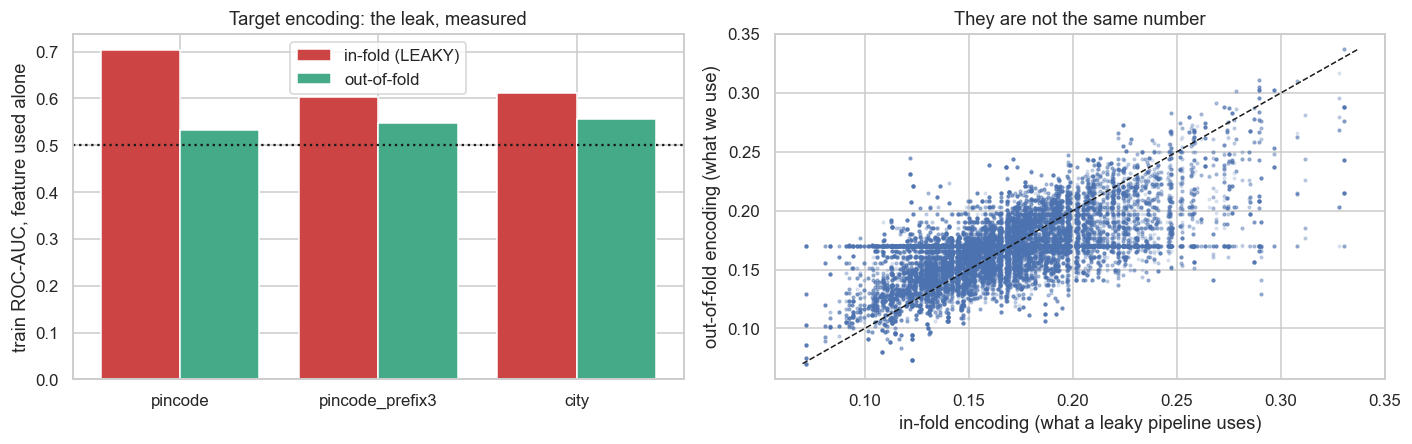


The leaky encoding of `pincode` alone scores 0.703 on train, against
0.534 for the correct out-of-fold version -- an inflation of
0.170 AUC bought entirely from the labels of the rows being encoded.

That inflation would have shown up as a strong train score, a mysteriously weaker
validation score, and a model that looked fine until it met new pincodes. It is
the single most common way a submission like this quietly fails.


In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

x = np.arange(len(leak))
ax[0].bar(x - 0.2, leak.train_auc_LEAKY, 0.4, label="in-fold (LEAKY)", color="#c44")
ax[0].bar(x + 0.2, leak.train_auc_out_of_fold, 0.4, label="out-of-fold", color="#4a8")
ax[0].axhline(0.5, ls=":", c="k")
ax[0].set_xticks(x, leak.key)
ax[0].set_ylabel("train ROC-AUC, feature used alone")
ax[0].set_title("Target encoding: the leak, measured")
ax[0].legend()

enc = OutOfFoldTargetEncoder(columns=("pincode",))
oof_p = enc.fit_transform(train[["pincode"]], y)["pincode_te"]
full_p = enc.transform(train[["pincode"]])["pincode_te"]
ax[1].scatter(full_p, oof_p, s=3, alpha=0.15)
lims = [min(full_p.min(), oof_p.min()), max(full_p.max(), oof_p.max())]
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("in-fold encoding (what a leaky pipeline uses)")
ax[1].set_ylabel("out-of-fold encoding (what we use)")
ax[1].set_title("They are not the same number")
plt.tight_layout()
plt.savefig(FIG / "02_leakage_audit.png", bbox_inches="tight")
plt.show()

print(f"""
The leaky encoding of `pincode` alone scores {leak.train_auc_LEAKY.iat[0]:.3f} on train, against
{leak.train_auc_out_of_fold.iat[0]:.3f} for the correct out-of-fold version -- an inflation of
{leak.inflation.iat[0]:.3f} AUC bought entirely from the labels of the rows being encoded.

That inflation would have shown up as a strong train score, a mysteriously weaker
validation score, and a model that looked fine until it met new pincodes. It is
the single most common way a submission like this quietly fails.""")

## 13. Preprocessing pipeline definition

In [33]:
from src.models import (
    RARE_CATEGORY_MIN_COUNT,
    TARGET_ENCODING_SOURCES,
    build_preprocessor,
    model_input_columns,
    to_design_matrix,
)

print("""The pipeline is defined ONCE, in src/models.py, and imported by 03, 04
and 05. A pipeline redefined per notebook is a pipeline that silently diverges.

  numeric      -> median impute -> (optional) standardise
                  median impute only affects past_rto_rate, whose missingness is
                  structural; has_history and is_first_order preserve the
                  distinction, so the imputation cannot erase it.

  categorical  -> one-hot, handle_unknown='infrequent_if_exist',
                  min_frequency={} -- rare states are pooled rather than given a
                  column some fold never sees.

  high-card    -> OutOfFoldTargetEncoder INSIDE the ColumnTransformer.
                  This placement is the whole point: sklearn calls fit_transform
                  on sub-transformers during fit, so training rows receive
                  out-of-fold encodings while transform() applies the
                  train-fitted mapping. Doing this outside the pipeline is the
                  leak measured in section 12.
""".format(RARE_CATEGORY_MIN_COUNT))

print("model input columns:", len(model_input_columns()))
print("target-encoded from:", TARGET_ENCODING_SOURCES)

The pipeline is defined ONCE, in src/models.py, and imported by 03, 04
and 05. A pipeline redefined per notebook is a pipeline that silently diverges.

  numeric      -> median impute -> (optional) standardise
                  median impute only affects past_rto_rate, whose missingness is
                  structural; has_history and is_first_order preserve the
                  distinction, so the imputation cannot erase it.

  categorical  -> one-hot, handle_unknown='infrequent_if_exist',
                  min_frequency=50 -- rare states are pooled rather than given a
                  column some fold never sees.

  high-card    -> OutOfFoldTargetEncoder INSIDE the ColumnTransformer.
                  This placement is the whole point: sklearn calls fit_transform
                  on sub-transformers during fit, so training rows receive
                  out-of-fold encodings while transform() applies the
                  train-fitted mapping. Doing this outside the pipeline is th

In [34]:
pre_trees = build_preprocessor(scale=False)   # trees / boosting
pre_linear = build_preprocessor(scale=True)   # logistic regression, MLP

X_train = to_design_matrix(pre_trees, train, train[TARGET], fit=True)
print(f"design matrix: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print()
print("expansion:")
print(f"  numeric            {len(NUMERIC_FEATURES):>3}")
print(f"  one-hot            {sum(c.startswith(tuple(f'{k}_' for k in CATEGORICAL_FEATURES)) for c in X_train.columns):>3}")
print(f"  target-encoded     {len(TARGET_ENCODING_SOURCES):>3}")
display(X_train.head(3).round(4))

design matrix: 35,000 rows x 66 columns

expansion:
  numeric             25
  one-hot             38
  target-encoded       3


,order_value,log_order_value,discount_pct,discount_amount,delivery_days_est,account_age_days,log_account_age,order_velocity_24h,past_orders,past_rto_count,...,state_Punjab,state_Rajasthan,state_Tamil Nadu,state_Uttar Pradesh,state_Uttaranchal,state_West Bengal,state_infrequent_sklearn,pincode_te,pincode_prefix3_te,city_te
0,1657.0,7.4134,0.155,256.83,3.7,102.43,4.6389,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1696,0.1696,0.1696
1,1351.0,7.2093,0.134,181.03,2.2,44.47,3.8171,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1696,0.1696,0.1696
2,189.0,5.2470,0.259,48.95,3.7,1.53,0.9282,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1696,0.1696,0.1696


In [35]:
# Sanity: no raw high-cardinality key survived into the design matrix, and the
# only columns present are ones we declared.
assert not {"pincode", "city", "pincode_prefix3"} & set(X_train.columns)
assert X_train.isna().sum().sum() == 0, "design matrix must be dense"
assert np.isfinite(X_train.to_numpy()).all()
print("design matrix is dense, finite, and contains no raw identifier columns")

summary = {
    "n_train": int(len(train)),
    "train_window": [str(train.order_ts.min().date()), str(train.order_ts.max().date())],
    "base_rate": float(base),
    "cod_rto_rate": float(cod[TARGET].mean()),
    "prepaid_rto_rate": float(prepaid[TARGET].mean()),
    "first_order_share": float(train.is_first_order.mean()),
    "design_matrix_shape": list(X_train.shape),
    "rate_by_tier": tier["rate"].round(4).to_dict(),
    "cod_rate_by_value_band": band["rate"].round(4).to_dict(),
    "rate_by_category": cat["rate"].round(4).to_dict(),
    "single_feature_auc": screen.set_index("feature")["auc"].round(4).to_dict(),
    "target_encoding_leak": leak.set_index("key")[
        ["train_auc_LEAKY", "train_auc_out_of_fold", "inflation"]].round(4).to_dict(),
    "top_vif": vif.head(8).set_index("feature")["vif"].round(2).to_dict(),
    "bayes_ceiling_roc_auc": BAYES_CEILING_AUC,
}
with open(RES / "02_eda_summary.json", "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2)
print(f"wrote {(RES / '02_eda_summary.json').relative_to(ROOT)}")

design matrix is dense, finite, and contains no raw identifier columns
wrote reports\results\02_eda_summary.json


---

## What 02 established

| | |
|---|---|
| Base rate | 17.0% overall, 26.6% on COD |
| Dominant driver | payment mode, then geography tier, then category |
| Non-monotonic value curve | confirmed at decile resolution, not a binning artefact |
| Strongest single feature | `is_cod` at AUC 0.711 — nothing near the 0.869 ceiling |
| Weakest kept features | `order_velocity_24h`, `account_age_days`, `addr_gibberish_score` — all kept, all declared weak *before* SHAP sees them |
| Measured leak | in-fold pincode encoding inflates train AUC by ~0.16 |
| Class handling | no resampling, no SMOTE — calibration is required for a cost threshold |
| Outliers | kept; they are the behaviour the scorer exists to price |

**Test set: still unopened.** Validation: still unopened.

**Next:** `03_model_training.ipynb` — 10 models plus a majority-class baseline, same
folds, same seed, same features, ranked on validation PR-AUC.